#1: Dependencies and library imports

In [1]:
from sklearn.datasets import make_circles
n_samples=1000

X,y=make_circles(n_samples,noise=0.03,random_state=42)

#2: View the raw data

In [2]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 y labels:
[1 1 1 1 0]


#3: Sorting data in Pandas DataFrame

In [4]:
import pandas as pd
circles=pd.DataFrame({"X1":X[:,0],
                      "X2": X[:, 1],
                        "label": y
                      })
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


#4. Checking Class Balance

In [5]:
circles.label.value_counts()

,count
label,
1,500
0,500


#5.Plotting the Data

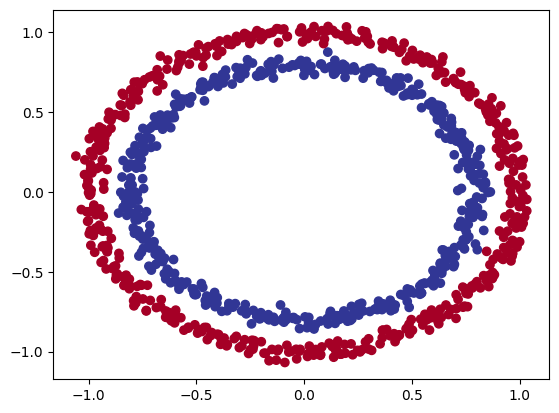

In [6]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0], y=X[:, 1], c=y, cmap=plt.cm.RdYlBu);

#6: Convert NumPy array to PyTorch Tensor

In [7]:
import torch
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

X[:5],y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

#7.Train-Test Split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

#8: Device Agnostic Code (CPU/GPU Selection)

In [10]:
import torch
from torch import nn

device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

#9: Creating a Neural Network Model

In [11]:
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer1=nn.Linear(in_features=2,out_features=5)
    self.layer2=nn.Linear(in_features=5,out_features=1)

  def forward(self,x):
    return self.layer2(self.layer1(x))
model_0=CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)

#10: Loss Function and Optimizer Selection

In [13]:
loss_fn=nn.BCEWithLogitsLoss()
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.1)

#11: Accuracy Evaluation Function

In [14]:
def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item()
  acc=(correct / len(y_pred)) * 100
  return acc

#12.Setup Tensors to Device

In [15]:

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

#13.Training & Testing Loop

In [17]:
torch.manual_seed(42)
epochs=100

for epoch in range(epochs):
  model_0.train()

  y_logits=model_0(X_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits))

  loss=loss_fn(y_logits,y_train)
  acc=accuracy_fn(y_true=y_train,y_pred=y_pred)

  optimizer.zero_grad()
  loss.backward()

  optimizer.step()

  model_0.eval()
  with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test,
                               y_pred=test_pred)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.70026, Acc: 50.00% | Test Loss: 0.70178, Test Acc: 50.00%
Epoch: 10 | Loss: 0.69593, Acc: 59.25% | Test Loss: 0.69760, Test Acc: 55.50%
Epoch: 20 | Loss: 0.69458, Acc: 52.38% | Test Loss: 0.69619, Test Acc: 52.50%
Epoch: 30 | Loss: 0.69409, Acc: 51.38% | Test Loss: 0.69562, Test Acc: 51.50%
Epoch: 40 | Loss: 0.69387, Acc: 50.88% | Test Loss: 0.69533, Test Acc: 50.50%
Epoch: 50 | Loss: 0.69373, Acc: 51.00% | Test Loss: 0.69514, Test Acc: 51.00%
Epoch: 60 | Loss: 0.69362, Acc: 50.50% | Test Loss: 0.69500, Test Acc: 50.50%
Epoch: 70 | Loss: 0.69354, Acc: 50.38% | Test Loss: 0.69489, Test Acc: 51.00%
Epoch: 80 | Loss: 0.69346, Acc: 50.12% | Test Loss: 0.69480, Test Acc: 50.50%
Epoch: 90 | Loss: 0.69340, Acc: 50.50% | Test Loss: 0.69472, Test Acc: 49.50%


#14.Building new models with non-linearity

In [25]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()
  def forward(self,x):
   return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
model_1 = CircleModelV1().to(device)
model_1


CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

#15.New Model Loss & Optimizer Setup

In [29]:
loss_fn=nn.BCEWithLogitsLoss()
optimizer=torch.optim.SGD(model_1.parameters(),lr=0.1)

#16: Training Loop for New Model (Training with Non-Linearity)

In [30]:
torch.manual_seed(42)
epochs=1000

X_train,y_train=X_train.to(device),y_train.to(device)
X_test,y_test=X_test.to(device),y_test.to(device)


for epoch in range(epochs):
  y_logits=model_1(X_train).squeeze()

  y_pred=torch.round(torch.sigmoid(y_logits))

  loss=loss_fn(y_logits,y_pred)
  acc=accuracy_fn(y_true=y_train,y_pred=y_pred)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_1.eval()
  with torch.inference_mode():
     test_logits = model_1(X_test).squeeze()
     test_pred = torch.round(torch.sigmoid(test_logits))
     test_loss = loss_fn(test_logits, y_test)
     test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)
if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")


#17.Decision Boundary Plotting Function

In [31]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists, skipping download")
else:
    print("Downloading helper_functions.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


#Linear vs Non-Linear Model Decision Boundary

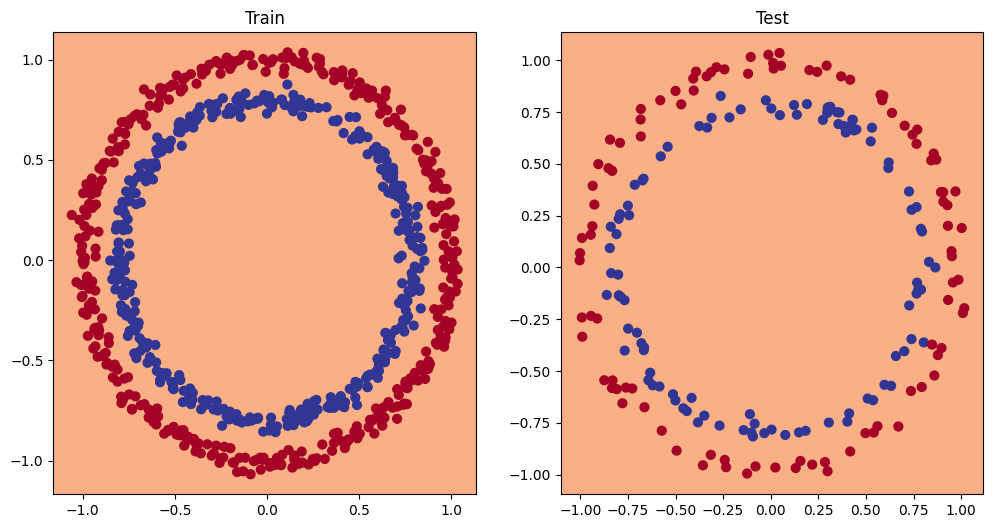

In [38]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)


plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)
